In [ ]:
1. Muhammad 'Ammar bin Mohd Jailani (sw01083747)
2. Adiputra bin Mohd Suki (sw01083729)

In [3]:
pip install gensim nltk pyLDAvis

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Name: Adiputra Bin Mohd Suki
# Student ID: SW01083729
#Name: Muhammad 'Ammar Bin Mohd Jailani
#Student ID: SW01083747
# Lab Assignment 3: Topic Modeling using LDA
#Import Libraries

import pandas as pd
import numpy as np
import re
import nltk
import gensim
import gensim.corpora as corpora
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from gensim.models import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [24]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [25]:
#Read Dataset
df = pd.read_csv("news_dataset.csv")

df.head()

,Unnamed: 0,text,target,title,date
0,0,I was wondering if anyone out there could enli...,7,rec.autos,2022-08-02 13:48:37.251043
1,17,I recently posted an article asking what kind ...,7,rec.autos,2022-08-02 13:48:37.251043
2,29,\nIt depends on your priorities. A lot of peo...,7,rec.autos,2022-08-02 13:48:37.251043
3,56,an excellent automatic can be found in the sub...,7,rec.autos,2022-08-02 13:48:37.251043
4,64,: Ford and his automobile. I need information...,7,rec.autos,2022-08-02 13:48:37.251043


In [26]:
df.columns


Index(['Unnamed: 0', 'text', 'target', 'title', 'date'], dtype='object')

In [27]:
df = df[['text']]
df.head()

,text
0,I was wondering if anyone out there could enli...
1,I recently posted an article asking what kind ...
2,\nIt depends on your priorities. A lot of peo...
3,an excellent automatic can be found in the sub...
4,: Ford and his automobile. I need information...


In [28]:
#check missing values
df.isnull().sum()


text    218
dtype: int64

In [29]:
df = df.dropna(subset=['text'])
df.isnull().sum()

text    0
dtype: int64

In [30]:
#text preprocessing
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # convert to lowercase
    text = text.lower()
    
    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # split into words
    words = text.split()
    
    # remove stopwords
    words = [word for word in words if word not in stop_words and len(word) > 2]
    
    # stemming
    words = [stemmer.stem(word) for word in words]
    
    # lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return words

In [ ]:
#apply preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)

df.head()

In [ ]:
#remove empty processed rows
df = df[df['processed_text'].map(len) > 0]
df.shape

In [14]:
#create dictionaries and corpus
id2word = corpora.Dictionary(df['processed_text'])

corpus = [id2word.doc2bow(text) for text in df['processed_text']]

In [15]:
print(corpus[0])

[(0, 1), (1, 2), (2, 1), (3, 1), (4, 1), (5, 1), (6, 4), (7, 1), (8, 1), (9, 2), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 2), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1)]


In [16]:
#build LDA model with 4 topics
lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=4,
    random_state=42,
    chunksize=100,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

In [18]:
#display topics
topics = lda_model.print_topics(num_words=10)

for topic in topics:
    print(topic)

(0, '0.007*"van" + 0.005*"pt" + 0.003*"period" + 0.003*"cal" + 0.003*"bo" + 0.003*"steven" + 0.003*"chi" + 0.003*"det" + 0.002*"tor" + 0.002*"leaf"')
(1, '0.020*"mov" + 0.005*"blbh" + 0.005*"bhb" + 0.003*"istanbul" + 0.003*"ptr" + 0.003*"ankara" + 0.002*"trinomi" + 0.002*"int" + 0.002*"molest" + 0.002*"bhcssimaxbyt"')
(2, '0.008*"would" + 0.008*"peopl" + 0.008*"one" + 0.005*"dont" + 0.005*"govern" + 0.005*"say" + 0.005*"know" + 0.005*"think" + 0.005*"like" + 0.004*"right"')
(3, '0.026*"key" + 0.021*"use" + 0.018*"encrypt" + 0.013*"chip" + 0.010*"system" + 0.008*"inform" + 0.008*"program" + 0.008*"bit" + 0.008*"anonym" + 0.007*"privaci"')


In [19]:
coherence_model_lda = CoherenceModel(
    model=lda_model,
    texts=df['processed_text'],
    dictionary=id2word,
    coherence='c_v'
)

coherence_score = coherence_model_lda.get_coherence()

print("Coherence Score:", coherence_score)

Coherence Score: 0.6139054039158872


In [20]:
def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    dominant_topic = max(topic_probs, key=lambda x: x[1])
    return dominant_topic[0]

df['dominant_topic'] = [get_dominant_topic(bow) for bow in corpus]

df.head()

,text,processed_text,dominant_topic
0,I was wondering if anyone out there could enli...,"[wonder, anyon, could, enlighten, car, saw, da...",2
1,I recently posted an article asking what kind ...,"[recent, post, articl, ask, kind, rate, singl,...",2
2,\nIt depends on your priorities. A lot of peo...,"[depend, prioriti, lot, peopl, put, higher, pr...",2
3,an excellent automatic can be found in the sub...,"[excel, automat, found, subaru, legaci, switch...",2
4,: Ford and his automobile. I need information...,"[ford, automobil, need, inform, whether, ford,...",2


In [21]:
topic_counts = df['dominant_topic'].value_counts().sort_index()

topic_counts

dominant_topic
0      56
1      29
2    8443
3    2468
Name: count, dtype: int64

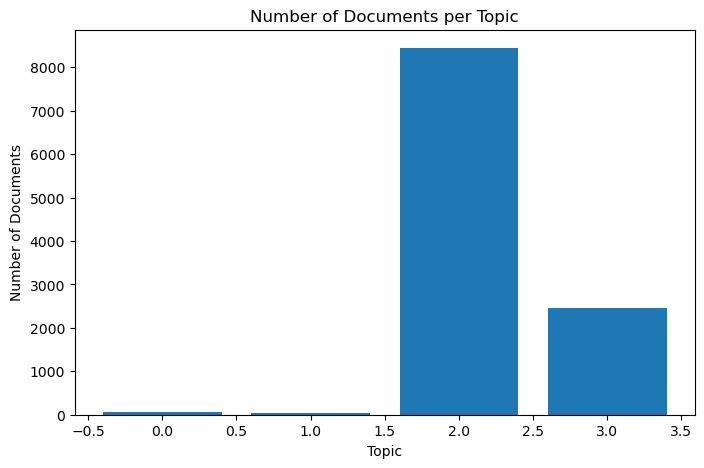

In [22]:
plt.figure(figsize=(8,5))
plt.bar(topic_counts.index, topic_counts.values)
plt.xlabel("Topic")
plt.ylabel("Number of Documents")
plt.title("Number of Documents per Topic")
plt.show()

## Interpretation of Coherence Score

The LDA model was trained using 4 topics based on the text column from the news dataset. The coherence score obtained was 0.6139054039158872. This score is used to evaluate how meaningful and interpretable the generated topics are. A higher coherence score means that the words within each topic are more related to each other and easier to understand. Based on the result, the model is able to group the news texts into different topic categories, although some topics may still overlap because the dataset contains various types of news content. Overall, the coherence score shows that the LDA model provides a reasonable topic structure for exploring hidden themes in the dataset.